In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB,CategoricalNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import  classification_report

In [3]:
df = pd.read_excel("Raisin_Dataset.xlsx")

In [4]:
df.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Class
0,87524,442.246011,253.291155,0.819738,90546,0.758651,1184.040,Kecimen
1,75166,406.690687,243.032436,0.801805,78789,0.684130,1121.786,Kecimen
2,90856,442.267048,266.328318,0.798354,93717,0.637613,1208.575,Kecimen
3,45928,286.540559,208.760042,0.684989,47336,0.699599,844.162,Kecimen
4,79408,352.190770,290.827533,0.564011,81463,0.792772,1073.251,Kecimen


In [5]:
df.shape

(900, 8)

In [6]:
df["Class"].value_counts()

Class
Kecimen    450
Besni      450
Name: count, dtype: int64

In [7]:
df.columns

Index(['Area', 'MajorAxisLength', 'MinorAxisLength', 'Eccentricity',
       'ConvexArea', 'Extent', 'Perimeter', 'Class'],
      dtype='object')

In [8]:
df.isna().sum()

Area               0
MajorAxisLength    0
MinorAxisLength    0
Eccentricity       0
ConvexArea         0
Extent             0
Perimeter          0
Class              0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             900 non-null    int64  
 1   MajorAxisLength  900 non-null    float64
 2   MinorAxisLength  900 non-null    float64
 3   Eccentricity     900 non-null    float64
 4   ConvexArea       900 non-null    int64  
 5   Extent           900 non-null    float64
 6   Perimeter        900 non-null    float64
 7   Class            900 non-null    object 
dtypes: float64(5), int64(2), object(1)
memory usage: 56.4+ KB


In [11]:
df.describe()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter
count,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000
mean,87804.127778,430.929950,254.488133,0.781542,91186.090000,0.699508,1165.906636
std,39002.111390,116.035121,49.988902,0.090318,40769.290132,0.053468,273.764315
min,25387.000000,225.629541,143.710872,0.348730,26139.000000,0.379856,619.074000
25%,59348.000000,345.442898,219.111126,0.741766,61513.250000,0.670869,966.410750
50%,78902.000000,407.803951,247.848409,0.798846,81651.000000,0.707367,1119.509000
75%,105028.250000,494.187014,279.888575,0.842571,108375.750000,0.734991,1308.389750
max,235047.000000,997.291941,492.275279,0.962124,278217.000000,0.835455,2697.753000


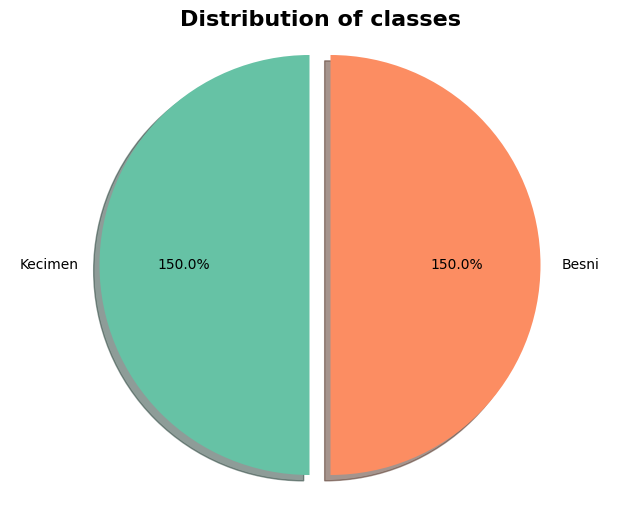

In [12]:
class_counts = df["Class"].value_counts()

plt.figure(figsize=(8,6))
plt.pie(
    class_counts,
    labels=class_counts.index,
    autopct="1%.1f%%",
    startangle = 90,
    explode = [0.05] * len(class_counts),
    shadow=True,
    colors=plt.cm.Set2.colors
)
plt.title("Distribution of classes",fontsize = 16,fontdict={"fontweight":"bold"})
plt.ylabel("")
plt.axis("equal")
plt.show()

In [13]:
df1 = df.drop("Class",axis=1)

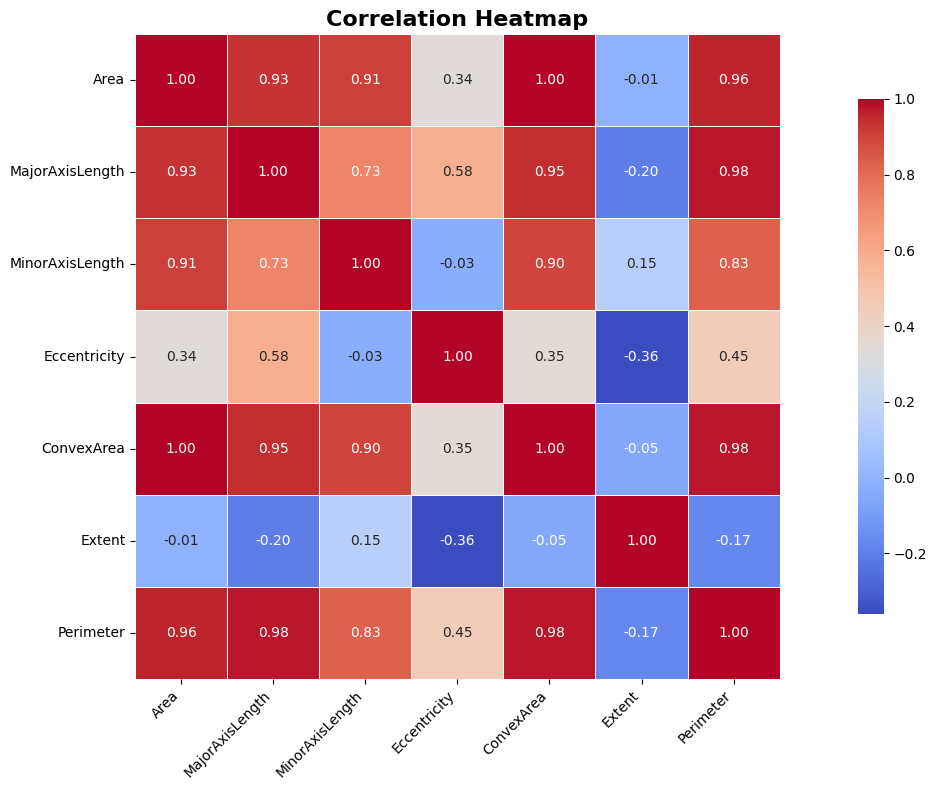

In [14]:
plt.figure(figsize=(16,8))
corr = df1.corr()
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    linecolor="white",
    square=True,
    cbar_kws={"shrink":.8},
    annot_kws={"size":10}
)
plt.title("Correlation Heatmap",fontsize = 16,fontdict={"fontweight":"bold"})
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation = 0)
plt.tight_layout()
plt.show()

In [15]:
x = df.drop(["Class"],axis=1)
y = df[["Class"]]

In [16]:
xtrain,xtest,ytrain,ytest = train_test_split(x,y,test_size=0.2,random_state=42)

In [21]:
gnb = GaussianNB()
mnnb = MultinomialNB()
bnb = BernoulliNB()

In [22]:
models = {
    "Gaussian_NB":gnb,
    "Multinomial_NB": mnnb,
    "Bernoulli_NB":bnb,
}

In [26]:
df.iloc[160]

Area                    47771
MajorAxisLength    311.524987
MinorAxisLength    197.090849
Eccentricity         0.774426
ConvexArea              49237
Extent               0.683409
Perimeter             857.776
Class                 Kecimen
Name: 160, dtype: object

In [27]:
for name,model in models.items():
    print("Model name is: ", name)
    model_data = model.fit(xtrain,ytrain)
    tr_sc = model_data.score(xtrain,ytrain)
    print(f"train score is: {tr_sc}")
    #pred = model.predict(xtest)
    #print(classification_report(ytest,pred))
    print(model_data.predict([[47771,311.524987,197.090849,0.774426
,49237,0.683409,857.776]]))
    print("<----------------->") 

Model name is:  Gaussian_NB
train score is: 0.8222222222222222
['Kecimen']
<----------------->
Model name is:  Multinomial_NB
train score is: 0.7805555555555556
['Kecimen']
<----------------->
Model name is:  Bernoulli_NB
train score is: 0.5055555555555555
['Besni']
<----------------->


c:\Users\h\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\h\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(
c:\Users\h\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\h\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MultinomialNB was fitted with feature names
